# Exploratory Data Analysis (EDA) – Secondary Data

This section explores the secondary dataset — YouTube statistics for the Joe Rogan
Experience podcast, obtained from Kaggle ("Joe Rogan Podcast Youtube Data," uploaded by
Joshi) — to provide broader context for the primary findings.

In [ ]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.rcParams["figure.dpi"] = 150

## 1. Load the Raw Data

The raw dataset was obtained from Kaggle as a JSON file and loaded into a DataFrame for
processing.

In [ ]:
with open("jre_yt.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print("Shape:", df.shape)
df.head()

Shape: (1324, 32)


,added,author,category_id,cc_license,comments,description,dislikes,duration,encrypted_id,end,...,user_id,views,timestamp_created,year,month,day,Episode,views_raw,duration_minutes,guest
0,08/09/2020,PowerfulJRE,22,False,"22,216","Ron White is a stand up comedian and actor, be...",4905,2:53:43,1mgN8r1mwvM,10423,...,zQUP1qoWDoEbmsQxvdjxgQ,"2,501,489",1599600996000,2020,9,8,1534,2501489,173,Ron White
1,07/09/2020,PowerfulJRE,22,False,"51,005","Adam Curry is a podcaster, announcer, internet...",20978,3:18:23,fTPQ9KR5j8k,11903,...,zQUP1qoWDoEbmsQxvdjxgQ,"3,310,357",1599237415000,2020,9,4,1533,3310357,198,Adam Curry
2,03/09/2020,PowerfulJRE,22,False,"27,382",Mike Tyson is the former undisputed heavyweigh...,3059,2:04:12,hcPUoxTvw5g,7452,...,zQUP1qoWDoEbmsQxvdjxgQ,"5,208,650",1599067206000,2020,9,2,1532,5208650,124,Mike Tyson
3,01/09/2020,PowerfulJRE,22,False,"43,109","Miley Cyrus is a singer-songwriter, actress, a...",17537,2:06:32,D7WUMXKV-FE,7592,...,zQUP1qoWDoEbmsQxvdjxgQ,"5,546,407",1598918337000,2020,8,31,1531,5546407,126,Miley Cyrus
4,31/08/2020,PowerfulJRE,22,False,"35,958","Duncan Trussell is a stand-up comedian, and ho...",8192,5:19:49,8xRz8ra9mdI,19189,...,zQUP1qoWDoEbmsQxvdjxgQ,"4,328,520",1598047220000,2020,8,21,1530,4328520,319,Duncan Trussell


## 2. Filtering and Cleaning

To maintain a consistent definition of a full episode, videos matching the main
"Joe Rogan Experience #..." title format were retained, while titles explicitly
indicating split parts were excluded. Duplicate video IDs were also removed. The likes
and comments fields were converted from comma-formatted strings into integers.

In [ ]:
pattern = re.compile(r"^Joe Rogan Experience #\d+")
df_full = df[df["title"].str.match(pattern, na=False)].copy()
df_full = df_full[~df_full["title"].str.contains("part", case=False, na=False)]
df_full = df_full.drop_duplicates(subset="encrypted_id")

for col in ["likes", "comments"]:
    df_full[col] = df_full[col].astype(str).str.replace(",", "").astype(int)
df_full["views"] = df_full["views_raw"].astype(int)

n = len(df_full)
print("Filtered full episodes:", n)
print("Year range:", df_full["year"].min(), "-", df_full["year"].max())

Filtered full episodes: 1111
Year range: 2014 - 2020


### Observation

Filtering reduced the dataset from 1,324 videos to **1,111 full episodes**, published
between **2014 and 2020**. No missing values were found in the variables used for this
analysis (duration, views, likes, comments), so no imputation was needed.

## 3. Distribution of Episode Duration (Figure 8.2.1)

The distribution of episode duration was examined to understand the typical length of Joe
Rogan Experience episodes.

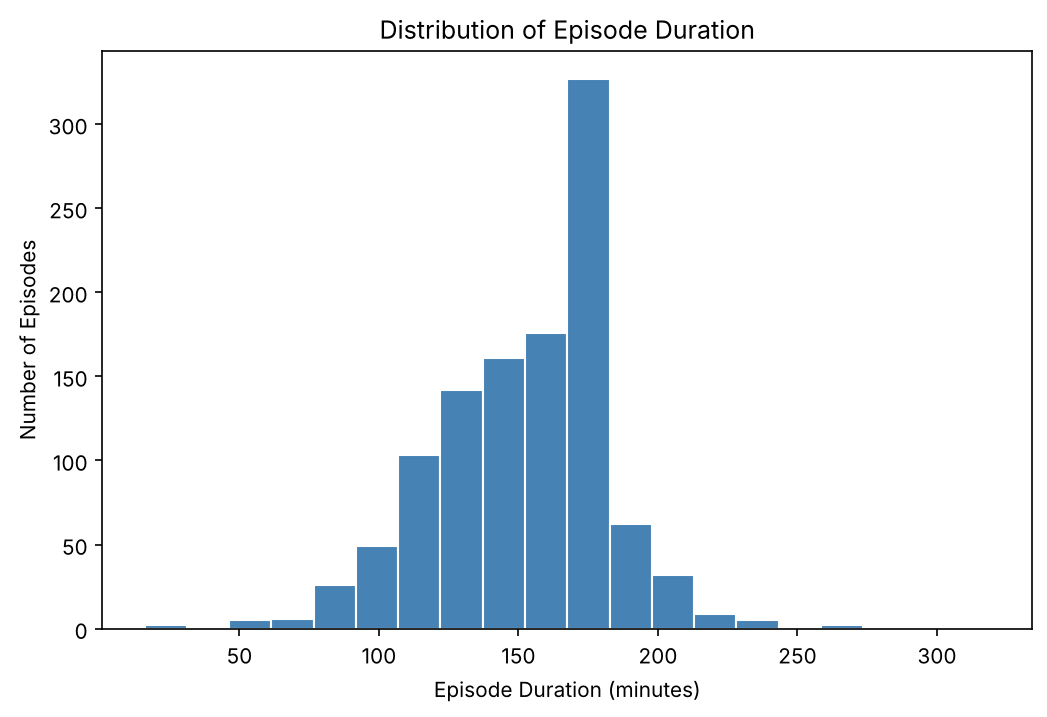

count    1111.000000
mean      152.957696
std        31.626494
min        16.000000
25%       133.000000
50%       158.000000
75%       175.000000
max       319.000000
Name: duration_minutes, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_full["duration_minutes"], bins=20, color="steelblue", edgecolor="white")
ax.set_title("Distribution of Episode Duration")
ax.set_xlabel("Episode Duration (minutes)")
ax.set_ylabel("Number of Episodes")
plt.show()

print(df_full["duration_minutes"].describe())

### Observation

Episode durations are mainly concentrated between **150 and 180 minutes**, with a mean of
**153.0 minutes** and a median of **158.0 minutes**, confirming that the dataset is
dominated by long-form episodes. A small number of episodes fall well outside this range,
from about 16 minutes up to 319 minutes.

## 4. Episode Duration vs. Views (Figure 8.2.2)

The relationship between episode duration and audience reach was examined to check whether
longer episodes tend to attract more views.

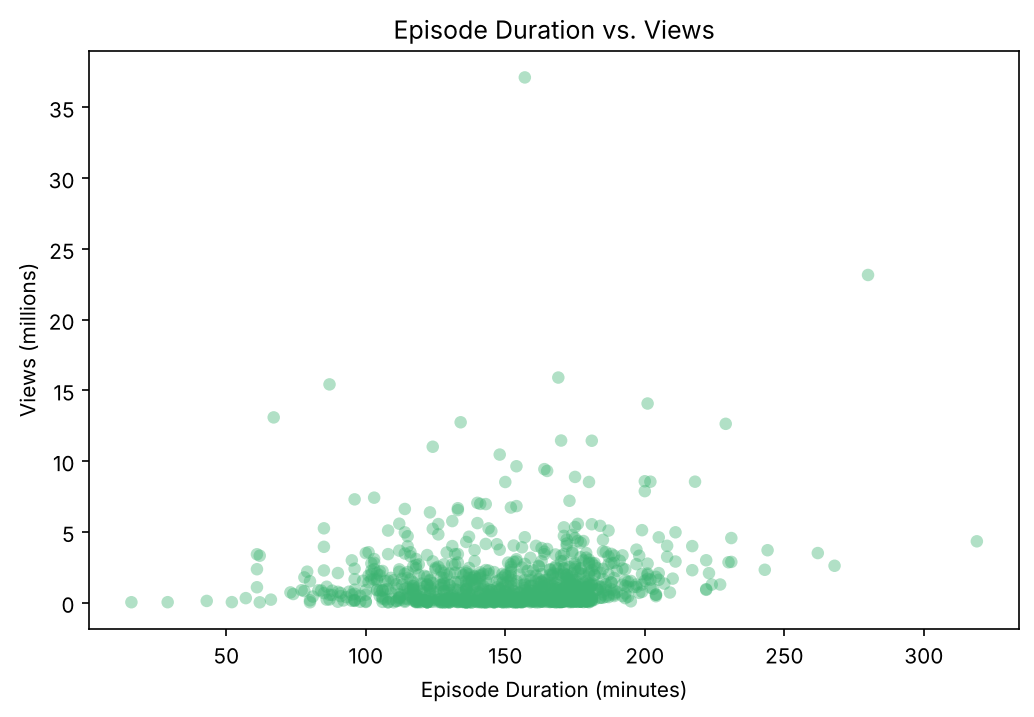

Pearson r = 0.082


In [ ]:
views_m = df_full["views"] / 1_000_000
r_dur_views, _ = pearsonr(df_full["duration_minutes"], df_full["views"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_full["duration_minutes"], views_m, alpha=0.4, color="mediumseagreen", edgecolor="none")
ax.set_title("Episode Duration vs. Views")
ax.set_xlabel("Episode Duration (minutes)")
ax.set_ylabel("Views (millions)")
plt.show()

print(f"Pearson r = {r_dur_views:.3f}")

### Observation

The correlation between duration and views is very weak (**r = 0.082**), indicating that
episode duration has little linear association with audience reach. Episodes of similar
length show very different view counts, and the highest-viewed episodes are spread across
a wide range of durations rather than clustering at a particular length.

## 5. Views vs. Comments (Figure 8.2.3)

The relationship between views and comments was examined to see whether greater reach is
associated with higher audience engagement.

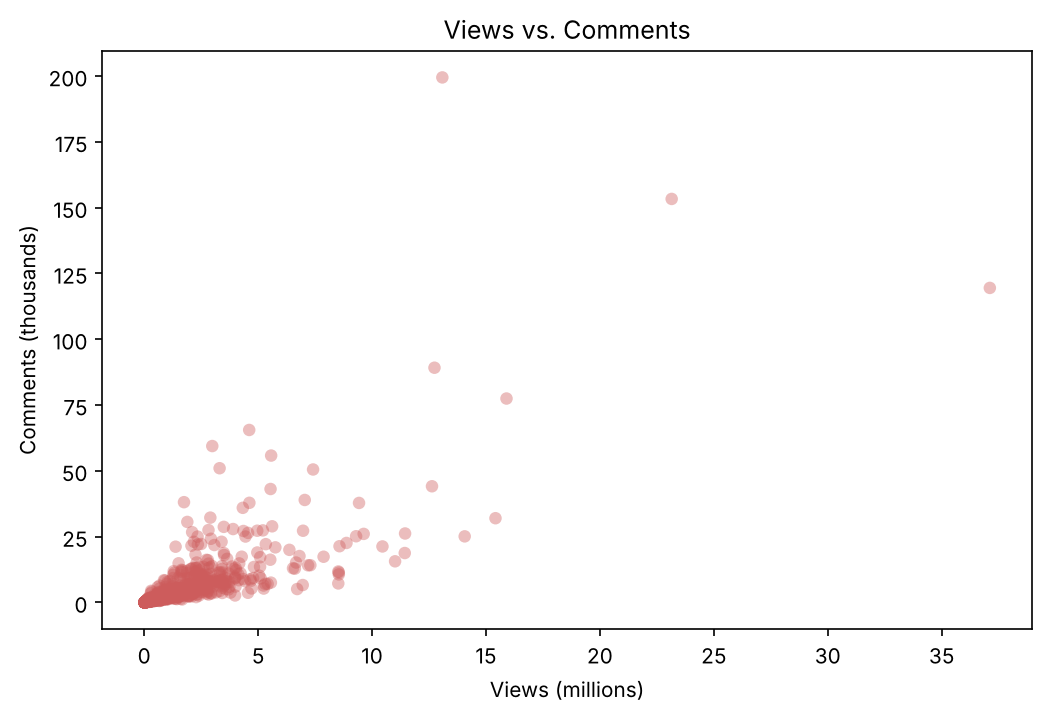

Pearson r = 0.764


In [ ]:
comments_k = df_full["comments"] / 1_000
r_views_comments, _ = pearsonr(df_full["views"], df_full["comments"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(views_m, comments_k, alpha=0.4, color="indianred", edgecolor="none")
ax.set_title("Views vs. Comments")
ax.set_xlabel("Views (millions)")
ax.set_ylabel("Comments (thousands)")
plt.show()

print(f"Pearson r = {r_views_comments:.3f}")

### Observation

Views and comments show a strong positive correlation (**r = 0.764**), meaning episodes
that reach more viewers also tend to receive more comments. A handful of highly-viewed
episodes also stand out with comment counts far above the rest of the dataset.

## 6. Distribution of Views (Figure 8.2.4)

The distribution of episode views was examined to understand how audience reach varies
across the dataset.

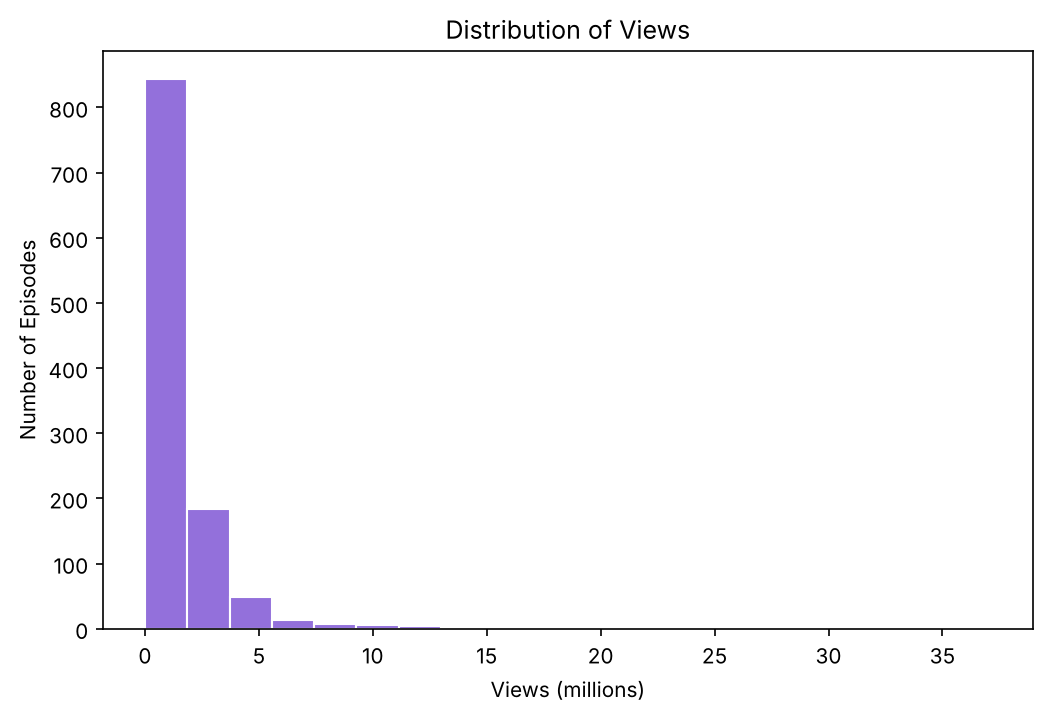

count    1.111000e+03
mean     1.366652e+06
std      2.259092e+06
min      9.323000e+03
25%      1.846220e+05
50%      6.635190e+05
75%      1.745111e+06
max      3.711326e+07
Name: views, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(views_m, bins=20, color="mediumpurple", edgecolor="white")
ax.set_title("Distribution of Views")
ax.set_xlabel("Views (millions)")
ax.set_ylabel("Number of Episodes")
plt.show()

print(df_full["views"].describe())

### Observation

Views are **strongly right-skewed**: the mean (**~1.37M**) is roughly double the median
(**~0.66M**), and the maximum reaches **37.11M**. Most episodes sit at relatively modest
view counts, while a small number of episodes achieve exceptionally high reach and pull
the average upward.

## 7. Correlation Analysis (Figure 8.2.5)

A correlation matrix was used to examine the relationships between duration, views, likes,
and comments.

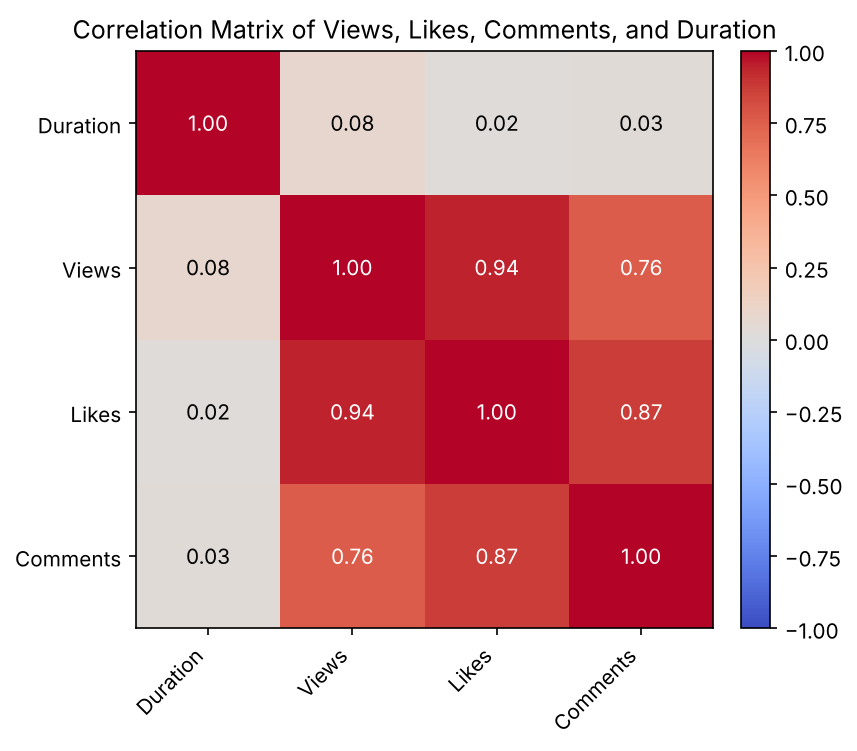

,Duration,Views,Likes,Comments
Duration,1.000000,0.081559,0.022570,0.029323
Views,0.081559,1.000000,0.943259,0.763884
Likes,0.022570,0.943259,1.000000,0.867402
Comments,0.029323,0.763884,0.867402,1.000000


In [ ]:
corr_df = pd.DataFrame({
    "Duration": df_full["duration_minutes"],
    "Views": df_full["views"],
    "Likes": df_full["likes"],
    "Comments": df_full["comments"],
})
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

ax.set_title("Correlation Matrix of Views, Likes, Comments, and Duration")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

corr_matrix

### Observation

Views, likes, and comments are all strongly correlated with each other (**r = 0.943** for
views-likes, **0.764** for views-comments, **0.867** for likes-comments), indicating that
these engagement metrics tend to increase together. Duration, in contrast, has very weak
correlations with the engagement variables, indicating little linear association between
episode length and audience reach or engagement.

## 8. Secondary EDA Summary

The analysis of the Joe Rogan Experience dataset showed that **views are strongly
right-skewed**, while **views, likes, and comments are strongly correlated with each
other**. Episode duration showed a **very weak linear association** with audience reach.

**Limitations:** the dataset was filtered from 1,324 to 1,111 episodes to keep a
consistent definition of a full episode; it represents a single channel, so the findings
may not generalize to other podcasts; and episodes were published between 2014 and 2020,
giving them different periods of exposure to accumulate engagement. Direct comparison with
the primary dataset should therefore
be made carefully, given differences in audience, time period, and data-collection
conditions.

**Reference:** Joshi. (2020). *Joe Rogan podcast YouTube data* [Data set]. Kaggle.
https://www.kaggle.com/datasets/shushie/joe-rogan-podcast-youtube-data